# **Análisis de Expresión Diferencial (PyDESeq2) y Enriquecimiento de Vías (GseaPy) - Proyecto Oncoflow**
**Pipeline:** RNA-seq Automatizado con Snakemake
**Objetivo:** Identificar genes diferencialmente expresados (DEGs) y rutas enriquecidas entre pacientes Respondedores (1.0) y No Respondedores (0.0).

Este notebook toma los conteos crudos generados por `featureCounts` y los metadatos del proyecto para realizar la normalización, el análisis estadístico y la extracción de características (transformación VST) que alimentarán los modelos de Machine Learning posteriores.

In [1]:
# ==============================================================================
# 1. STANDARD LIBRARY & SYSTEM
# ==============================================================================
import datetime as dt
import warnings
import joblib
import os

# ==============================================================================
# 2. DATA MANIPULATION & SCIENTIFIC COMPUTING
# ==============================================================================
import numpy as np
import pandas as pd
import pyarrow  # Engine para archivos Parquet (eficiencia en RNA-seq masivo)
from scipy import stats
import scipy

# ==============================================================================
# 3. BIOINFORMATICS & GENOMICS SPECIFIC
# ==============================================================================
import scanpy as sc         # Análisis de Single-Cell y Scanpy-objects
import gseapy as gp         # Enriquecimiento funcional (GSEA/Enrichr)
from gseapy.plot import dotplot, gseaplot, heatmap, ringplot, gseaplot2
import Bio.Seq              # Manipulación de secuencias biológicas


# ==============================================================================
# 4. MACHINE LEARNING: PREPROCESSING & DATA BALANCING
# ==============================================================================
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.manifold import TSNE

# ==============================================================================
# 5. MACHINE LEARNING: MODELS & OPTIMIZATION
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier      # Potente para datos tabulares de expresión
import optuna                         # Optimización Bayesiana de hiperparámetros

# ==============================================================================
# 6. DIMENSIONALITY REDUCTION & CLUSTERING
# ==============================================================================
import umap
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# ==============================================================================
# 7. EVALUATION & INTERPRETABILITY (Crucial para Bioética/IA)
# ==============================================================================
import shap  # Explicabilidad de caja negra (¿Qué genes mueven la predicción?)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, 
    classification_report, roc_auc_score, roc_curve
)

# ==============================================================================
# 8. VISUALIZATION CONFIGURATION
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sb

# Configuración de estilo
%matplotlib inline
sb.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = [10, 6]
warnings.filterwarnings('ignore')

print(f"Pipeline cargado exitosamente - {dt.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

c:\Users\sebat\miniforge3\envs\bio_ml_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Pipeline cargado exitosamente - 2026-05-12 15:00:07


In [2]:
# IMPORT DATA
#Cargar Resultados de PyDESeq2
deg_results = pd.read_csv("PyDESeq2_results.tsv", sep="\t", index_col=0)

### **Procesamiento de "pydeseq2_results.tsv"**

In [3]:
deg_results.head(30)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),Significant
Geneid,,,,,,,,
DDX11L1,48.751782,-0.067016,0.349110,-0.191964,0.847771,0.962229,0.016722,No significativo
WASH7P,3536.206144,-0.097050,0.182757,-0.531034,0.595395,0.867380,0.061791,No significativo
MIR6859-1,0.571312,-1.029814,1.025400,-1.004305,0.315232,1.000000,-0.000000,No significativo
MIR1302-2HG,1.694358,1.192781,0.734056,1.624919,0.104180,1.000000,-0.000000,No significativo
FAM138A,1.213043,0.043048,1.260897,0.034140,0.972765,1.000000,-0.000000,No significativo
OR4F5,2.846908,0.633567,0.965423,0.656258,0.511658,1.000000,-0.000000,No significativo
LOC124903816,0.944041,-0.189578,1.141183,-0.166124,0.868059,1.000000,-0.000000,No significativo
LOC124900384,22.177676,0.709763,0.302445,2.346753,0.018938,0.235406,0.628182,No significativo
LOC729737,5496.204395,0.316343,0.394825,0.801223,0.423002,0.778962,0.108484,No significativo


In [4]:
# Información general del dataframe
deg_results.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37740 entries, DDX11L1 to TRNP
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   baseMean        37740 non-null  float64
 1   log2FoldChange  37740 non-null  float64
 2   lfcSE           37740 non-null  float64
 3   stat            37740 non-null  float64
 4   pvalue          37740 non-null  float64
 5   padj            37740 non-null  float64
 6   -log10(padj)    37740 non-null  float64
 7   Significant     37740 non-null  object 
dtypes: float64(7), object(1)
memory usage: 2.6+ MB


In [5]:
# Estadísticas descriptivas del dataframe
deg_results.describe(include = 'all')

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),Significant
count,37740.000000,37740.000000,37740.000000,37740.000000,3.774000e+04,37740.000000,37740.000000,37740
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No significativo
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37611
mean,1412.088854,0.005399,1.052872,0.047937,5.235007e-01,0.804962,0.135992,NaN
std,8486.528260,0.790336,1.110630,1.122724,3.257893e-01,0.255340,0.236608,NaN
min,0.030486,-7.262920,0.083999,-5.770967,7.881804e-09,0.000182,-0.000000,NaN
25%,0.581678,-0.340140,0.321881,-0.548432,2.192851e-01,0.671663,-0.000000,NaN
50%,25.761997,0.018377,0.623654,0.031859,5.481664e-01,0.938052,0.027773,NaN
75%,692.484575,0.345809,1.388199,0.655559,8.373226e-01,1.000000,0.172849,NaN


In [6]:
# Valores nulos en los resultados de DESeq2
print("Valores nulos en los resultados de DESeq2:")
print(deg_results.isnull().sum())
deg_results[deg_results.isnull().any(axis=1)].head(20)

Valores nulos en los resultados de DESeq2:
baseMean          0
log2FoldChange    0
lfcSE             0
stat              0
pvalue            0
padj              0
-log10(padj)      0
Significant       0
dtype: int64


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),Significant
Geneid,,,,,,,,


In [8]:
# Valores duplicados en los resultados de DESeq2
print("Valores duplicados en los resultados de DESeq2:")
print(deg_results.duplicated().sum())
deg_results[deg_results.duplicated()].head(20)

Valores duplicados en los resultados de DESeq2:
6272


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),Significant
Geneid,,,,,,,,
LOC124903819,0.049255,-0.318236,3.253156,-0.097824,0.922072,1.0,-0.0,No significativo
LOC124904848,0.034855,0.264668,3.240695,0.081670,0.934909,1.0,-0.0,No significativo
MIR6730,0.034855,0.264668,3.240695,0.081670,0.934909,1.0,-0.0,No significativo
PRAMEF34P,0.117562,0.585266,3.209024,0.182381,0.855284,1.0,-0.0,No significativo
PRAMEF36P,0.117562,0.585266,3.209024,0.182381,0.855284,1.0,-0.0,No significativo
LOC105376809,0.045946,0.264668,3.240695,0.081670,0.934909,1.0,-0.0,No significativo
LOC105376817,0.068539,0.264668,3.240695,0.081670,0.934909,1.0,-0.0,No significativo
LOC124904816,0.030486,-0.318236,3.253156,-0.097824,0.922072,1.0,-0.0,No significativo
LOC105376826,0.054118,-0.318236,3.253156,-0.097824,0.922072,1.0,-0.0,No significativo


In [9]:
# Copiamos para no modificar el original inmediatamente
#deg_cleaned = deg_results.dropna()
deg_cleaned = deg_results.drop_duplicates()

# Imputamos los valores nulos
#deg_cleaned['padj'] = deg_cleaned['padj'].fillna(1.0)
#deg_cleaned['pvalue'] = deg_cleaned['pvalue'].fillna(1.0)


print(f"El shape del DataFrame es: {deg_cleaned.shape}")
deg_cleaned.head()

El shape del DataFrame es: (31468, 8)


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),Significant
Geneid,,,,,,,,
DDX11L1,48.751782,-0.067016,0.349110,-0.191964,0.847771,0.962229,0.016722,No significativo
WASH7P,3536.206144,-0.097050,0.182757,-0.531034,0.595395,0.867380,0.061791,No significativo
MIR6859-1,0.571312,-1.029814,1.025400,-1.004305,0.315232,1.000000,-0.000000,No significativo
MIR1302-2HG,1.694358,1.192781,0.734056,1.624919,0.104180,1.000000,-0.000000,No significativo
FAM138A,1.213043,0.043048,1.260897,0.034140,0.972765,1.000000,-0.000000,No significativo


In [10]:
def extract_iqr_outliers(df, column_name):
    """
    Calcula y extrae los valores atípicos (outliers) de una columna específica 
    de un DataFrame utilizando el método del Rango Intercuartílico (IQR).
    
    Parámetros:
    -----------
    df : pandas.DataFrame
        El dataframe con los resultados de PyDESeq2.
    column_name : str
        El nombre de la columna a analizar (ej. 'baseMean', 'log2FoldChange').
        
    Retorna:
    --------
    pandas.DataFrame
        Un subconjunto del dataframe original que contiene solo los outliers.
    """
    
    # Calcular cuartiles y el rango intercuartílico
    q25 = df[column_name].quantile(0.25)
    q75 = df[column_name].quantile(0.75)
    iqr = q75 - q25

    # Definir los límites
    lower_limit = q25 - 1.5 * iqr
    upper_limit = q75 + 1.5 * iqr

    # Filtrar el dataframe
    outliers_df = df[(df[column_name] > upper_limit) | (df[column_name] < lower_limit)]

    # Imprimir un resumen claro
    print(f"--- Análisis de Outliers para: '{column_name}' ---")
    print(f"Límite inferior: {lower_limit:.4f}")
    print(f"Límite superior: {upper_limit:.4f}")
    print(f"Número de genes atípicos detectados: {len(outliers_df)}\n")

    return outliers_df


In [11]:
# Identificación de outliers utilizando el método del Rango Intercuartílico (IQR)
# Para 'baseMean'
outliers_baseMean = extract_iqr_outliers(deg_cleaned, 'baseMean')

# Para 'log2FoldChange'
outliers_log2FoldChange = extract_iqr_outliers(deg_cleaned, 'log2FoldChange')

# Para 'stat'
outliers_stat = extract_iqr_outliers(deg_cleaned, 'stat')

--- Análisis de Outliers para: 'baseMean' ---
Límite inferior: -1532.5931
Límite superior: 2560.6543
Número de genes atípicos detectados: 4330

--- Análisis de Outliers para: 'log2FoldChange' ---
Límite inferior: -1.5258
Límite superior: 1.5133
Número de genes atípicos detectados: 2156

--- Análisis de Outliers para: 'stat' ---
Límite inferior: -2.9094
Límite superior: 3.0124
Número de genes atípicos detectados: 600



In [ ]:
# Definición de umbrales para clasificación de genes

PADJ_THRESHOLD = 0.05
LOG2FOLDCHANGE_THRESHOLD = 1.0

# Clasificación de genes en categorías basadas en los umbrales definidos
def classify_genes(row):
    if row['padj'] < PADJ_THRESHOLD and abs(row['log2FoldChange']) >= LOG2FOLDCHANGE_THRESHOLD:
        if row['log2FoldChange'] > 0:
            return 'Upregulated'
        else:
            return 'Downregulated'
    else:
        return 'Not Significant'
    
deg_cleaned['DEG_Category'] = deg_cleaned.apply(classify_genes, axis=1)


In [17]:
# Display first few rows of the dataframe
deg_cleaned = deg_cleaned.drop(columns='Significant')
deg_cleaned.head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,-log10(padj),DEG_Category
Geneid,,,,,,,,
DDX11L1,48.751782,-0.067016,0.349110,-0.191964,0.847771,0.962229,0.016722,Not Significant
WASH7P,3536.206144,-0.097050,0.182757,-0.531034,0.595395,0.867380,0.061791,Not Significant
MIR6859-1,0.571312,-1.029814,1.025400,-1.004305,0.315232,1.000000,-0.000000,Not Significant
MIR1302-2HG,1.694358,1.192781,0.734056,1.624919,0.104180,1.000000,-0.000000,Not Significant
FAM138A,1.213043,0.043048,1.260897,0.034140,0.972765,1.000000,-0.000000,Not Significant


Text(0.5, 1.0, 'Densidad de Genes (Hexbin Plot)')

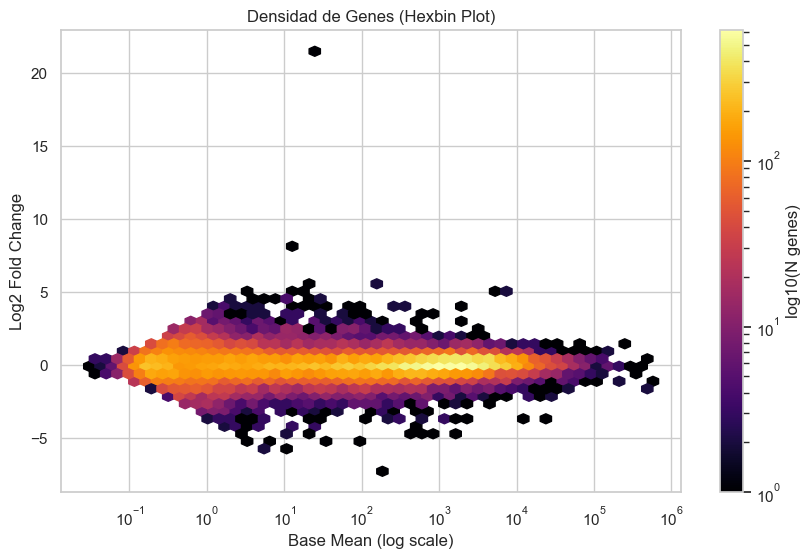

In [18]:
# Hexbin Plot para visualizar densidad (manejo de duplicados)
plt.figure(figsize=(10, 6))
plt.hexbin(deg_cleaned['baseMean'], deg_cleaned['log2FoldChange'], 
           gridsize=50, cmap='inferno', bins='log', xscale='log')
plt.colorbar(label='log10(N genes)')
plt.xlabel('Base Mean (log scale)')
plt.ylabel('Log2 Fold Change')
plt.title('Densidad de Genes (Hexbin Plot)')

Text(0.5, 1.0, 'MA Plot (Visualización estándar de DESeq2)')

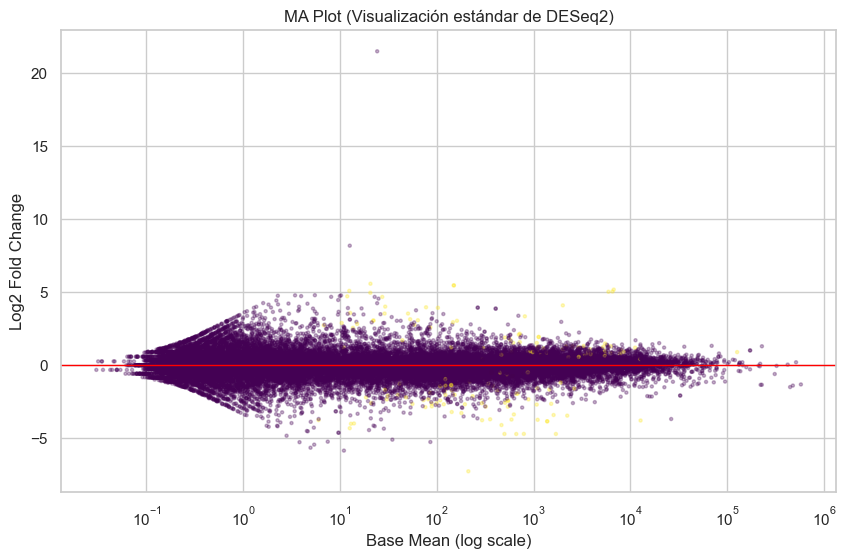

In [19]:
# MA Plot con escala log en baseMean
plt.figure(figsize=(10, 6))
plt.scatter(deg_cleaned['baseMean'], deg_cleaned['log2FoldChange'], 
            c=(deg_cleaned['padj'] < 0.05), cmap='viridis', alpha=0.3, s=5)
plt.xscale('log')
plt.axhline(0, color='red', lw=1)
plt.xlabel('Base Mean (log scale)')
plt.ylabel('Log2 Fold Change')
plt.title('MA Plot (Visualización estándar de DESeq2)')

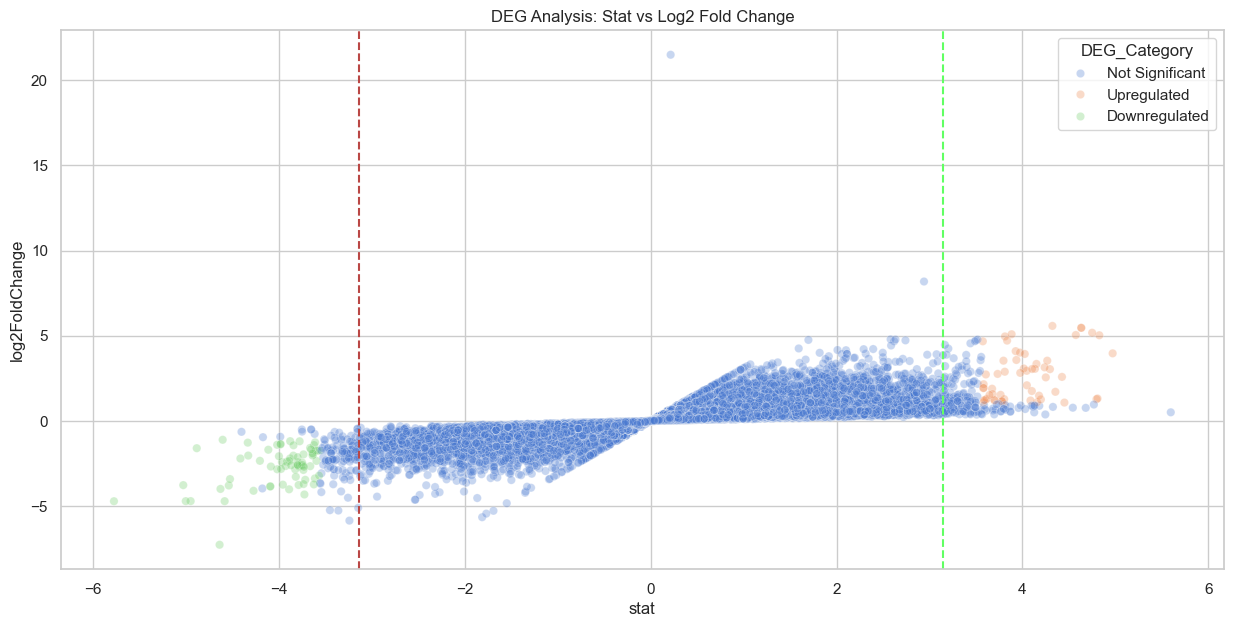

In [20]:
plt.figure(figsize = (15, 7))
sb.scatterplot(data = deg_cleaned, x='stat', y='log2FoldChange', hue='DEG_Category', alpha=0.3)
plt.axvline(x = -3.14, color="#ba4745", label='Downregulated', ls='--')
plt.axvline(x = 3.14, color='#61ff63', label='Upregulated', ls='--')
plt.title('DEG Analysis: Stat vs Log2 Fold Change')
plt.show()

**Volcano Plot**

In [51]:
# Extracción de genes significativos para análisis posterior
significant_genes = deg_cleaned[deg_cleaned['DEG_Category'] != 'Not Significant'].index.tolist()
print(f"Total de genes diferencialmente expresados: {len(significant_genes)}")
print(f"5 genes diferencialmente expresados: {significant_genes[:5]}")
genes_a_resaltar = significant_genes[:5]


Total de genes diferencialmente expresados: 127
5 genes diferencialmente expresados: ['ZFP69B', 'NTNG1', 'TBX15', 'ADCY10', 'RHEX']


In [24]:
# REACTOME ECM
genes_a_resaltar = [
    'COL14A1', 'ITGB4', 'COL17A1', 
    'ELN', 'COL6A6', 'CMA1', 'DST', 'LAMA3'
]

In [16]:
# CALMIDAZOLIUM 
genes_a_resaltar = [
    'SNORA48', 'PCDHGA12', 'PCDHGB6', 'SNORD10', 'PCDHGB3', 'PCDHGB1', 
    'PCDHGA4', 'PCDHGA5', 'PCDHGA9', 'HTRA1', 'PCDHGB7', 'SNORA67', 
    'PCDHGC4', 'PCDHGA6', 'PCDHGB2', 'PDS5B', 'PCDHGC5', 'CXCL12'
]

In [17]:
# CLORGILINA
genes_a_resaltar = [
    'DST', 'CDH23', 'UTRN', 'VPS13C', 'DYNC2H1', 'CFH', 'WDR17', 
    'MPP7', 'TSHR', 'PREX2', 'BAZ2B', 'APC', 'REV3L', 'CHD9', 
    'VPS13A', 'ZNF644', 'AR', 'MIPOL1', 'PHF3', 'TRIP11', 'SLC4A5'
]

In [22]:
# ADHESIÖN CELULAR
genes_a_resaltar = [
    'ITGB4', 'ARHGAP6', 'ANGPTL3', 'COL17A1', 'PPFIA2', 'TNN', 'NPNT', 
    'NID2', 'ADAMTS12', 'DLC1', 'ITGA11', 'ITGA8', 'ITGA10', 'L1CAM', 
    'ITGB3', 'FBLN5', 'PEAK1', 'ADAMTS9', 'ITGAV', 'COL3A1', 'ADAM9'
]

In [19]:
# DEGRADACIÓN ECM
genes_a_resaltar = [
    'COL14A1', 'COL17A1', 'ELN', 'COL6A6', 'CMA1', 'LAMA3', 'FBN1', 
    'COL1A2'
]

In [ ]:
# Biomarcadores comunes
genes_a_resaltar = [
    'BRCA2', 'PDCD1', 'IFNG', 'CD24', 'CTLA4'
]

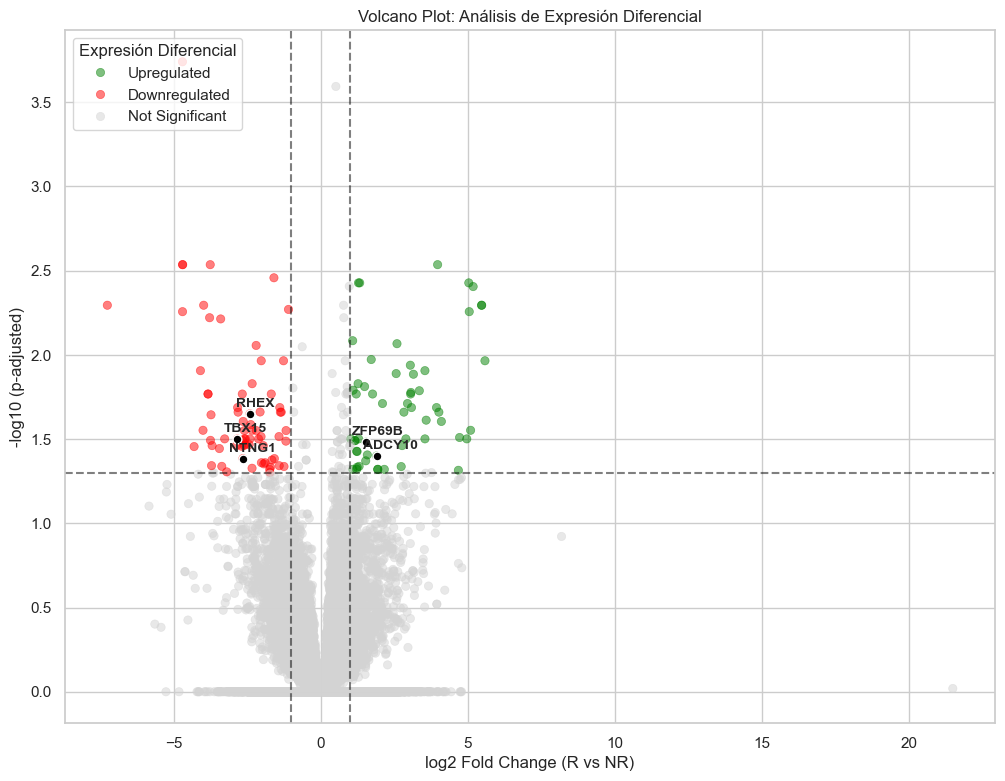

In [52]:
# 1. Definir la lista de genes de interés (Cambiar según la necesidad)


plt.figure(figsize=(12, 9))

# Plot principal
ax = sb.scatterplot(
    data=deg_cleaned, x='log2FoldChange', y=-np.log10(deg_cleaned['padj']),
    hue='DEG_Category', hue_order=['Upregulated', 'Downregulated', 'Not Significant'], 
    palette={'Not Significant': 'lightgrey', 'Upregulated': 'green', 'Downregulated': 'red'},
    alpha=0.5, edgecolor=None
)

# --- BLOQUE NUEVO: Anotación de genes específicos ---
for gene in genes_a_resaltar:
    # Ajusta 'index' por el nombre de tu columna si es necesario (ej. deg_cleaned['gene_name'])
    if gene in deg_cleaned.index:
        fila = deg_cleaned.loc[gene]
        x = fila['log2FoldChange']
        y = -np.log10(fila['padj'])
        
        # Dibujar el punto más marcado para que destaque
        plt.scatter(x, y, color='black', s=40, edgecolors='white', zorder=5)
        
        # Añadir la etiqueta de texto
        plt.annotate(
            gene, 
            xy=(x, y), 
            xytext=(-10, 5),               # Desplazamiento del texto respecto al punto
            textcoords='offset points', 
            fontsize=10, 
            fontweight='bold',

            zorder=6
        )

# Líneas de umbral
plt.axhline(y=1.3, color='black', linestyle='--', alpha=0.5) 
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5)   
plt.axvline(x=-1, color='black', linestyle='--', alpha=0.5)  

plt.legend(title='Expresión Diferencial', loc='upper left')
plt.title('Volcano Plot: Análisis de Expresión Diferencial')
plt.xlabel('log2 Fold Change (R vs NR)')
plt.ylabel('-log10 (p-adjusted)')

plt.show()

# **Pathway Enrichment**

In [33]:
print(f"Genes diferencialmente expresados: {len(significant_genes)}")

epsilon = np.finfo(float).eps
gseap_df = deg_cleaned[['log2FoldChange', 'pvalue']]
gseap_df['pvalue'] = gseap_df['pvalue'].replace(0, epsilon)

gseap_df['Ranking_Metric'] = gseap_df['log2FoldChange'] * -np.log10(gseap_df['pvalue'])
rnk_df = gseap_df.sort_values(by='Ranking_Metric', ascending=False)
rnk_df.reset_index(inplace=True)
rnk_df = rnk_df[['Geneid', 'Ranking_Metric']]
rnk_df.head()

Genes diferencialmente expresados: 127


,Geneid,Ranking_Metric
0,HSFY2,29.757049
1,HSFY1,29.741027
2,POTEH,29.467412
3,POTEM,29.463691
4,LOC101929572,26.844373


In [34]:
librerias_disponibles = gp.get_library_name(organism='Human')
print(f"Número de librerías disponibles para análisis de enriquecimiento: {len(librerias_disponibles)}")
print("Ejemplos de librerías disponibles:")
print(librerias_disponibles)

Número de librerías disponibles para análisis de enriquecimiento: 228
Ejemplos de librerías disponibles:
['ARCHS4_Cell-lines', 'ARCHS4_IDG_Coexp', 'ARCHS4_Kinases_Coexp', 'ARCHS4_TFs_Coexp', 'ARCHS4_Tissues', 'Achilles_fitness_decrease', 'Achilles_fitness_increase', 'Aging_Perturbations_from_GEO_down', 'Aging_Perturbations_from_GEO_up', 'Allen_Brain_Atlas_10x_scRNA_2021', 'Allen_Brain_Atlas_down', 'Allen_Brain_Atlas_up', 'Azimuth_2023', 'Azimuth_Cell_Types_2021', 'BioCarta_2013', 'BioCarta_2015', 'BioCarta_2016', 'BioPlanet_2019', 'BioPlex_2017', 'CCLE_Proteomics_2020', 'CM4AI_U2OS_Protein_Localization_Assemblies', 'COMPARTMENTS_Curated_2025', 'COMPARTMENTS_Experimental_2025', 'CORUM', 'COVID-19_Related_Gene_Sets', 'COVID-19_Related_Gene_Sets_2021', 'Cancer_Cell_Line_Encyclopedia', 'Carcinogenome', 'CellMarker_2024', 'CellMarker_Augmented_2021', 'ChEA_2013', 'ChEA_2015', 'ChEA_2016', 'ChEA_2022', 'Chromosome_Location', 'Chromosome_Location_hg19', 'ClinVar_2019', 'ClinVar_2025', 'DGIdb_

In [ ]:
# ==============================================================================
# Librerias posibles para consultar por función
# ==============================================================================

# Caso 1: Identificar el proceso biológico maestro
librerias_macro = [
    'MSigDB_Hallmark_2020', 
    'Enrichr_Libraries_Most_Popular_Genes'
]

# Caso 2: Mapear la ruta específica y la ontología
librerias_meso = [
    'KEGG_2021_Human', 
    'Reactome_Pathways_2024', 
    'WikiPathways_2024_Human',
    'GO_Biological_Process_2025',
    'BioPlanet_2019'
]

# Caso 3: Identificar Factores de Transcripción y reguladores
librerias_micro = [
    'ChEA_2022', 
    'TRRUST_Transcription_Factors_2019', 
    'JASPAR_PWM_Human_2025',
    'TargetScan_microRNA_2017',
    'ENCODE_TF_ChIP-seq_2015'
]

# Caso 4: Validar contra fármacos y firmas de respuesta
librerias_clinicas = [
    'LINCS_L1000_Chem_Pert_up', 
    'LINCS_L1000_Chem_Pert_down', 
    'DSigDB', 
    'DGIdb_Drug_Targets_2024',
    'DisGeNET'
]

# Caso 5: Localización y complejos proteicos
librerias_estructurales = [
    'CORUM', 
    'huMAP', 
    'COMPARTMENTS_Curated_2025',
    'Azimuth_2023'  # Si necesitas validar el tipo celular
]

# 

**DataBases Clínicas**

In [43]:

# Se realiza el análisis de enriquecimiento GSEA utilizando gseapy para datasets clinicos
pre_res_cln = gp.prerank(
    rnk=rnk_df,
    gene_sets=['Reactome_Pathways_2024'],  # Cambia según el caso que quieras analizar
    threads=4,
    min_size=15,    # Ignorar vías con menos de 15 genes detectados
    max_size=500,   # Ignorar vías demasiado generales (>500 genes)
    permutation_num=1000, # Permutaciones para calcular el p-valor
    outdir=None,    # Guardar en memoria para graficar en el notebook
    seed=42
)

# Se extraen los resultados de GSEA para cada base de datos
out = []

for term in list(pre_res_cln.results):
    out.append([term,
                pre_res_cln.results[term]['es'], 
                pre_res_cln.results[term]['nes'], 
                pre_res_cln.results[term]['pval'], 
                pre_res_cln.results[term]['fdr']])
gsea_cln_results_df = pd.DataFrame(out, columns=['Term', 'ES', 'NES', 'p-value', 'FDR'])
gsea_cln_results_df = gsea_cln_results_df.sort_values(by='NES', ascending=False)
gsea_cln_results_df.head(20)


2026-05-12 15:31:16,199 [WARNING] Duplicated values found in preranked stats: 3.74% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,ES,NES,p-value,FDR
1204,Reactome_Pathways_2024__Cell Cycle Checkpoints,0.812087,2.254387,0.0,0.0
558,Reactome_Pathways_2024__G2 M Checkpoints,0.843167,2.150932,0.0,0.0
1212,Reactome_Pathways_2024__M Phase,0.747613,2.144036,0.0,0.0
680,Reactome_Pathways_2024__Homology Directed Repair,0.822770,2.090943,0.0,0.0
1032,Reactome_Pathways_2024__Mitotic Prometaphase,0.767935,2.089723,0.0,0.0
63,Reactome_Pathways_2024__HDR Through Homologous...,0.820167,2.062550,0.0,0.0
548,Reactome_Pathways_2024__Resolution of Sister C...,0.801542,2.056435,0.0,0.0
1255,Reactome_Pathways_2024__Mitotic Metaphase and ...,0.751049,2.055662,0.0,0.0
760,Reactome_Pathways_2024__Processing of DNA Doub...,0.861472,2.054023,0.0,0.0
729,Reactome_Pathways_2024__Mitotic Anaphase,0.749170,2.050301,0.0,0.0


In [45]:
# Se extraen los resultados de GSEA para cada base de datos

sig_pathways_cln = gsea_cln_results_df[gsea_cln_results_df['FDR'] < 0.005]
print(f"Vías significativas encontradas: {len(sig_pathways_cln)}")
print(sig_pathways_cln[['Term', 'FDR']].head(10))

Vías significativas encontradas: 126
                                                   Term  FDR
1204     Reactome_Pathways_2024__Cell Cycle Checkpoints  0.0
558            Reactome_Pathways_2024__G2 M Checkpoints  0.0
1212                    Reactome_Pathways_2024__M Phase  0.0
680    Reactome_Pathways_2024__Homology Directed Repair  0.0
1032       Reactome_Pathways_2024__Mitotic Prometaphase  0.0
63    Reactome_Pathways_2024__HDR Through Homologous...  0.0
548   Reactome_Pathways_2024__Resolution of Sister C...  0.0
1255  Reactome_Pathways_2024__Mitotic Metaphase and ...  0.0
760   Reactome_Pathways_2024__Processing of DNA Doub...  0.0
729            Reactome_Pathways_2024__Mitotic Anaphase  0.0


In [ ]:
# 1. Seleccionamos las vías (términos) que queremos comparar
# Puedes usar tus strings manuales o sacarlos de los resultados
terms_cln = sig_pathways_cln['Term'].tolist()

# 2. Extraemos los datos necesarios de los resultados (pre_res)
# Usamos una comprensión de lista para obtener 'hits' y 'RES' de cada vía
hits = [pre_res_cln.results[t]['hits'] for t in terms_cln]
runes = [pre_res_cln.results[t]['RES'] for t in terms_cln]

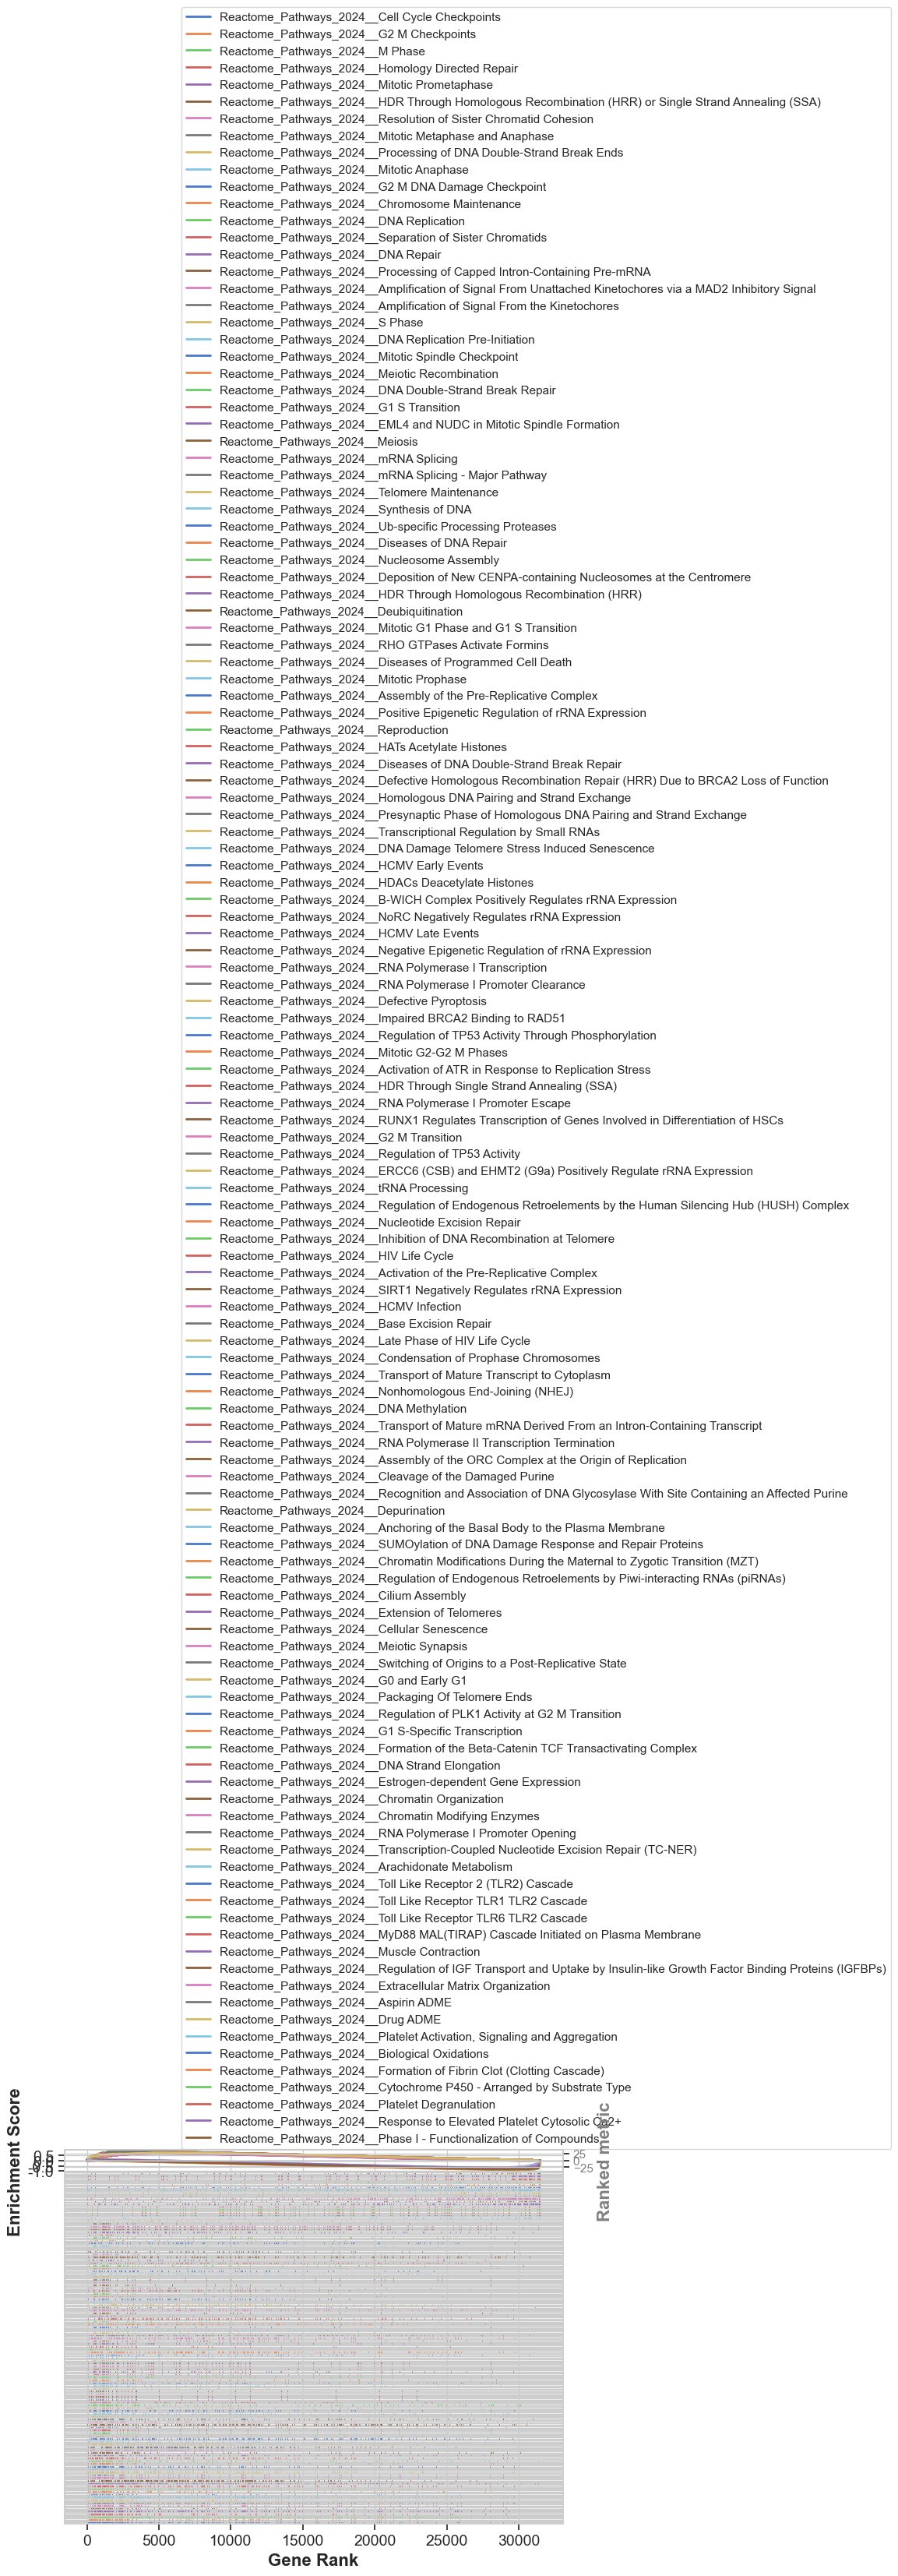

In [47]:
# 3. Graficamos usando gseaplot2
# Esta función está diseñada para encimar las curvas y comparar
fig = gseaplot2(terms=terms_cln, 
                RESs=runes, 
                hits=hits,
                rank_metric=pre_res_cln.ranking, # El ranking es el mismo para todas
                legend_kws={'loc': (0.235, 1.05)}, # Mueve la leyenda fuera de la gráfica
                figsize=(8, 6),
                title="Comparación de Respuesta Biológica")

plt.show()

In [48]:
gsea_cln_results = pre_res_cln.res2d

# 1. Identificamos las vías de interés (basado en tus resultados previos)
vias_objetivo = terms_cln

# 2. Extraemos los genes líderes del DataFrame de resultados
# Filtramos el DataFrame res2d por los términos que queremos
df_lideres_raw = gsea_cln_results[gsea_cln_results['Term'].isin(vias_objetivo)]

# 3. Limpiamos y organizamos
genes_por_via = {}

for _, row in df_lideres_raw.iterrows():
    via = row['Term']
    # En GSEApy, la columna suele llamarse 'Lead_genes'
    # Si te da error, intenta con row['Genes']
    genes_string = row['Lead_genes'] 
    
    lista_genes = genes_string.split(';')
    genes_por_via[via] = lista_genes
    print(f"Vía: {via} -> {len(lista_genes)} genes líderes extraídos con éxito.")

# 4. Guardar para tu validación posterior
# (Usamos este método para manejar listas de diferentes longitudes)
df_final = pd.DataFrame.from_dict(genes_por_via, orient='index').transpose()

# 5. Guardar en .csv
df_final.to_csv("genes_lideres_validados_Reactome.csv", index=False)

Vía: Reactome_Pathways_2024__Cell Cycle Checkpoints -> 120 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__G2 M Checkpoints -> 68 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__M Phase -> 145 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__Homology Directed Repair -> 64 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__Mitotic Prometaphase -> 83 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__HDR Through Homologous Recombination (HRR) or Single Strand Annealing (SSA) -> 58 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__Resolution of Sister Chromatid Cohesion -> 63 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__Mitotic Metaphase and Anaphase -> 89 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__Processing of DNA Double-Strand Break Ends -> 44 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__Mitotic Anaphase -> 88 genes líderes extraídos con éxit

**DataBases Biológicas**

In [34]:

# Se realiza el análisis de enriquecimiento GSEA utilizando gseapy para datasets biológicos
pre_res_meso = gp.prerank(
    rnk=rnk_df,
    gene_sets=['Reactome_Pathways_2024'],  # Cambia según el caso que quieras analizar
    threads=4,
    min_size=15,    # Ignorar vías con menos de 15 genes detectados
    max_size=500,   # Ignorar vías demasiado generales (>500 genes)
    permutation_num=1000, # Permutaciones para calcular el p-valor
    outdir=None,    # Guardar en memoria para graficar en el notebook
    seed=42
)

# Se extraen los resultados de GSEA para cada base de datos
out = []

for term in list(pre_res_meso.results):
    out.append([term,
                pre_res_meso.results[term]['es'], 
                pre_res_meso.results[term]['nes'], 
                pre_res_meso.results[term]['pval'], 
                pre_res_meso.results[term]['fdr']])
gsea_meso_results_df = pd.DataFrame(out, columns=['Term', 'ES', 'NES', 'p-value', 'FDR'])
gsea_meso_results_df = gsea_meso_results_df.sort_values(by='NES', ascending=False)
gsea_meso_results_df.head(20)


,Term,ES,NES,p-value,FDR
463,Reactome_Pathways_2024__Assembly of Collagen F...,0.848755,1.700796,0.000000,0.061475
237,Reactome_Pathways_2024__O-linked Glycosylation,0.804553,1.693240,0.000000,0.039959
457,Reactome_Pathways_2024__Degradation of the Ext...,0.780720,1.691582,0.000000,0.028396
35,Reactome_Pathways_2024__Collagen Formation,0.799656,1.685160,0.000000,0.028103
571,Reactome_Pathways_2024__HCMV Late Events,0.802095,1.679556,0.000000,0.027049
818,Reactome_Pathways_2024__Extracellular Matrix O...,0.723725,1.669434,0.000000,0.035275
916,Reactome_Pathways_2024__Diseases Associated Wi...,0.830150,1.646356,0.002990,0.061852
835,Reactome_Pathways_2024__HDACs Deacetylate Hist...,0.823647,1.640178,0.001468,0.063451
187,Reactome_Pathways_2024__RUNX1 Regulates Genes ...,0.816847,1.636416,0.001531,0.062646
877,Reactome_Pathways_2024__Collagen Chain Trimeri...,0.867402,1.635934,0.001520,0.056733


In [35]:
# Se extraen los resultados de GSEA para cada base de datos

sig_pathways_meso = gsea_meso_results_df[gsea_meso_results_df['FDR'] < 0.05]
print(f"Vías significativas encontradas: {len(sig_pathways_meso)}")
print(sig_pathways_meso[['Term', 'FDR']].head(len(sig_pathways_meso)))

Vías significativas encontradas: 5
                                                  Term       FDR
237     Reactome_Pathways_2024__O-linked Glycosylation  0.039959
457  Reactome_Pathways_2024__Degradation of the Ext...  0.028396
35          Reactome_Pathways_2024__Collagen Formation  0.028103
571           Reactome_Pathways_2024__HCMV Late Events  0.027049
818  Reactome_Pathways_2024__Extracellular Matrix O...  0.035275


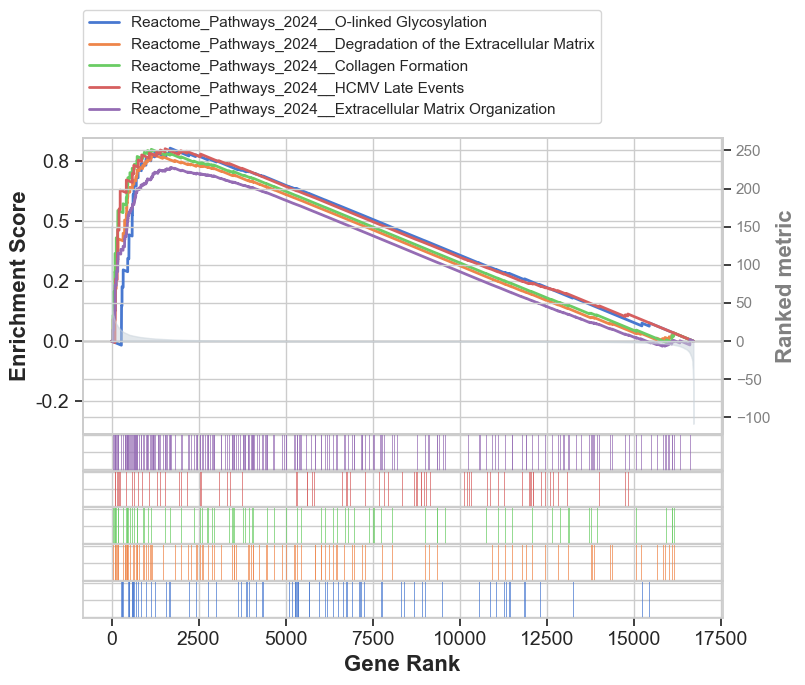

In [36]:
gsea_meso_results = pre_res_meso.res2d

# 1. Seleccionamos las vías (términos) que queremos comparar
# Puedes usar tus strings manuales o sacarlos de los resultados
terms_meso = sig_pathways_meso['Term'].tolist()

# 2. Extraemos los datos necesarios de los resultados (pre_res)
# Usamos una comprensión de lista para obtener 'hits' y 'RES' de cada vía
hits = [pre_res_meso.results[t]['hits'] for t in terms_meso]
runes = [pre_res_meso.results[t]['RES'] for t in terms_meso]

# 3. Graficamos usando gseaplot2
# Esta función está diseñada para encimar las curvas y comparar
fig = gseaplot2(terms=terms_meso, 
                RESs=runes, 
                hits=hits,
                rank_metric=pre_res_meso.ranking, # El ranking es el mismo para todas
                legend_kws={'loc': (0, 1.05)}, # Mueve la leyenda fuera de la gráfica
                figsize=(8, 6),
                title="Comparación de Respuesta Biológica")

plt.show()

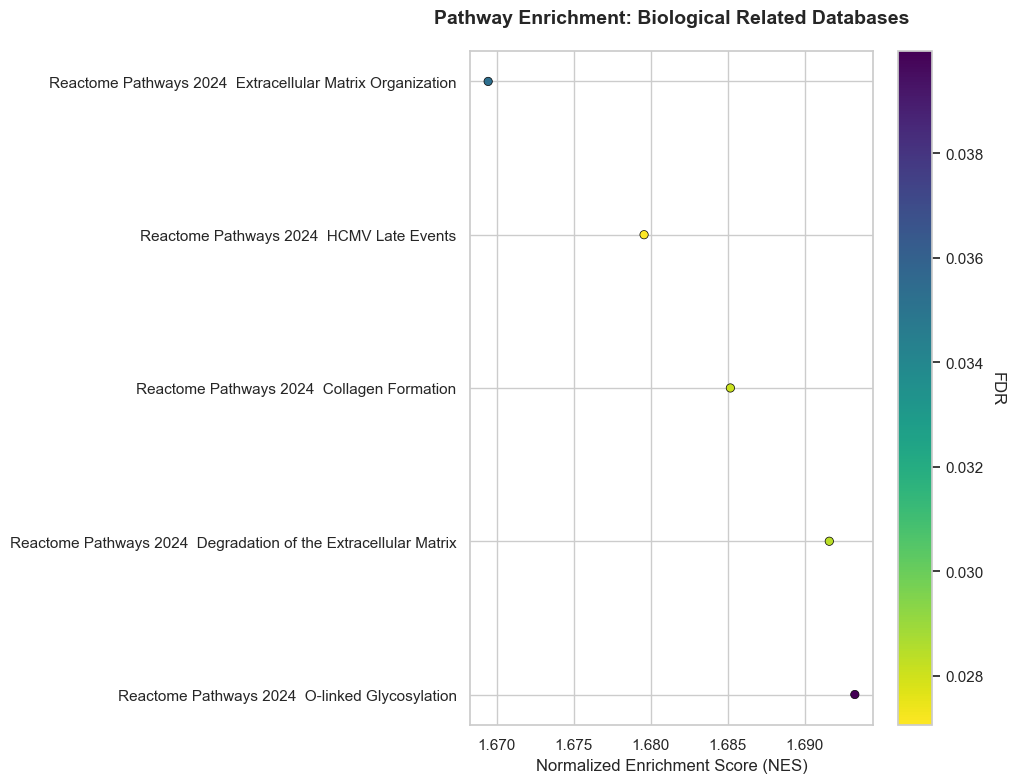

In [37]:
# Mostrar las vías significativas

# 1. Filtramos y preparamos datos
df_plot = gsea_meso_results_df[gsea_meso_results_df['FDR'] < 0.05].copy()
# Opcional: Acortar nombres muy largos de Reactome para que quepan mejor
df_plot['Term'] = df_plot['Term'].str.split('R-HSA').str[0].str.replace('_', ' ')

# 2. Configurar el estilo
plt.figure(figsize=(10, 8))
sb.set_style("whitegrid")

# 3. Crear el scatter plot (el dotplot manual)
# Usamos -log10 del FDR para que los colores sean más intuitivos si prefieres, 
# pero aquí mantendremos FDR directo para no confundirte.
scatter = plt.scatter(
    x=df_plot['NES'], 
    y=df_plot['Term'], 
    c=df_plot['FDR'], 
    cmap='viridis_r', # Invertido: colores claros = FDR bajo (más significativo)
    edgecolors="black", 
    linewidth=0.5
)

# 4. Ajustes finos de los ejes
plt.title('Pathway Enrichment: Biological Related Databases', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Normalized Enrichment Score (NES)', fontsize=12)
plt.ylabel('') # Quitamos el label de Y porque los nombres de las rutas ya son claros

# 5. Añadir barra de color para el FDR
cbar = plt.colorbar(scatter)
cbar.set_label('FDR', rotation=270, labelpad=15)

# 6. Mejorar el espaciado para que no se corte el texto
plt.tight_layout()
plt.show()

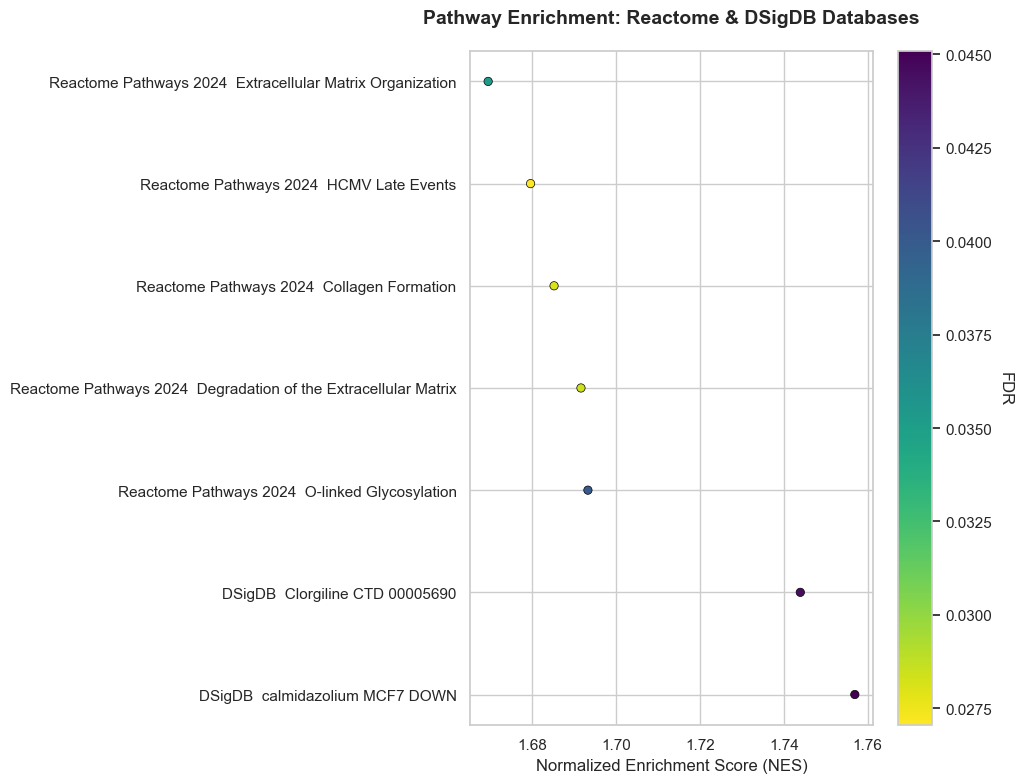

In [38]:
# Mostrar las vías significativas

# 1. Filtramos y preparamos datos
df_plot_a = gsea_cln_results_df[gsea_cln_results_df['FDR'] < 0.05].copy()
df_plot_b = gsea_meso_results_df[gsea_meso_results_df['FDR'] < 0.05].copy()

df_plot = pd.concat([df_plot_a, df_plot_b], ignore_index=True)
# Opcional: Acortar nombres muy largos de Reactome para que quepan mejor
df_plot['Term'] = df_plot['Term'].str.split('R-HSA').str[0].str.replace('_', ' ')

# 2. Configurar el estilo
plt.figure(figsize=(10, 8))
sb.set_style("whitegrid")

# 3. Crear el scatter plot (el dotplot manual)
# Usamos -log10 del FDR para que los colores sean más intuitivos si prefieres, 
# pero aquí mantendremos FDR directo para no confundirte.
scatter = plt.scatter(
    x=df_plot['NES'], 
    y=df_plot['Term'], 
    c=df_plot['FDR'], 
    cmap='viridis_r', # Invertido: colores claros = FDR bajo (más significativo)
    edgecolors="black", 
    linewidth=0.5
)

# 4. Ajustes finos de los ejes
plt.title('Pathway Enrichment: Reactome & DSigDB Databases', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Normalized Enrichment Score (NES)', fontsize=12)
plt.ylabel('') # Quitamos el label de Y porque los nombres de las rutas ya son claros

# 5. Añadir barra de color para el FDR
cbar = plt.colorbar(scatter)
cbar.set_label('FDR', rotation=270, labelpad=15)

# 6. Mejorar el espaciado para que no se corte el texto
plt.tight_layout()
plt.show()

In [45]:
# 1. Identificamos las vías de interés (basado en tus resultados previos)
vias_objetivo = terms_meso

# 2. Extraemos los genes líderes del DataFrame de resultados
# Filtramos el DataFrame res2d por los términos que queremos
df_lideres_raw = gsea_meso_results[gsea_meso_results['Term'].isin(vias_objetivo)]

# 3. Limpiamos y organizamos
genes_por_via = {}

for _, row in df_lideres_raw.iterrows():
    via = row['Term']
    # En GSEApy, la columna suele llamarse 'Lead_genes'
    # Si te da error, intenta con row['Genes']
    genes_string = row['Lead_genes'] 
    
    lista_genes = genes_string.split(';')
    genes_por_via[via] = lista_genes
    print(f"Vía: {via} -> {len(lista_genes)} genes líderes extraídos con éxito.")

# 4. Guardar para tu validación posterior
# (Usamos este método para manejar listas de diferentes longitudes)
df_final = pd.DataFrame.from_dict(genes_por_via, orient='index').transpose()

# 5. Guardar en .csv
df_final.to_csv("genes_lideres_validados_Reactome.csv", index=False)

Vía: Reactome_Pathways_2024__O-linked Glycosylation -> 21 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__Degradation of the Extracellular Matrix -> 29 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__Collagen Formation -> 21 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__HCMV Late Events -> 15 genes líderes extraídos con éxito.
Vía: Reactome_Pathways_2024__Extracellular Matrix Organization -> 66 genes líderes extraídos con éxito.


**Librerías de Procesos Macro**

In [52]:

# Se realiza el análisis de enriquecimiento GSEA utilizando gseapy para datasets
pre_res_FT = gp.prerank(
    rnk=rnk_df,
    gene_sets=librerias_macro,  # Cambia según el caso que quieras analizar
    threads=4,
    min_size=15,    # Ignorar vías con menos de 15 genes detectados
    max_size=500,   # Ignorar vías demasiado generales (>500 genes)
    permutation_num=1000, # Permutaciones para calcular el p-valor
    outdir=None,    # Guardar en memoria para graficar en el notebook
    seed=42
)

# Se extraen los resultados de GSEA para cada base de datos
out = []

for term in list(pre_res_FT.results):
    out.append([term,
                pre_res_FT.results[term]['es'], 
                pre_res_FT.results[term]['nes'], 
                pre_res_FT.results[term]['pval'], 
                pre_res_FT.results[term]['fdr']])
gsea_FT_results_df = pd.DataFrame(out, columns=['Term', 'ES', 'NES', 'p-value', 'FDR'])
gsea_FT_results_df = gsea_FT_results_df.sort_values(by='NES', ascending=False)
gsea_FT_results_df.head(20)


,Term,ES,NES,p-value,FDR
98,Enrichr_Libraries_Most_Popular_Genes__ARCHS4 T...,0.793920,1.709157,0.000000,0.006264
67,MSigDB_Hallmark_2020__UV Response Dn,0.744563,1.638750,0.001295,0.032216
42,Enrichr_Libraries_Most_Popular_Genes__dbGaP,0.795490,1.635516,0.000000,0.023565
69,Enrichr_Libraries_Most_Popular_Genes__Human Ph...,0.745555,1.596179,0.001387,0.049219
24,MSigDB_Hallmark_2020__Epithelial Mesenchymal T...,0.664759,1.510932,0.001224,0.182915
45,Enrichr_Libraries_Most_Popular_Genes__ENCODE T...,0.684971,1.432620,0.026798,0.436257
46,Enrichr_Libraries_Most_Popular_Genes__TargetSc...,0.675252,1.407120,0.033755,0.498836
145,Enrichr_Libraries_Most_Popular_Genes__Allen Br...,0.682850,1.403533,0.044321,0.453820
17,Enrichr_Libraries_Most_Popular_Genes__NCI-60 C...,0.629235,1.400757,0.021601,0.416023
40,Enrichr_Libraries_Most_Popular_Genes__GO Cellu...,0.649111,1.399497,0.034388,0.379880


In [53]:
# Se extraen los resultados de GSEA para cada base de datos

sig_pathways_FT = gsea_FT_results_df[gsea_FT_results_df['FDR'] < 0.05]
print(f"Vías significativas encontradas: {len(sig_pathways_FT)}")
print(sig_pathways_FT[['Term', 'FDR']].head(10))

Vías significativas encontradas: 4
                                                 Term       FDR
98  Enrichr_Libraries_Most_Popular_Genes__ARCHS4 T...  0.006264
67               MSigDB_Hallmark_2020__UV Response Dn  0.032216
42        Enrichr_Libraries_Most_Popular_Genes__dbGaP  0.023565
69  Enrichr_Libraries_Most_Popular_Genes__Human Ph...  0.049219


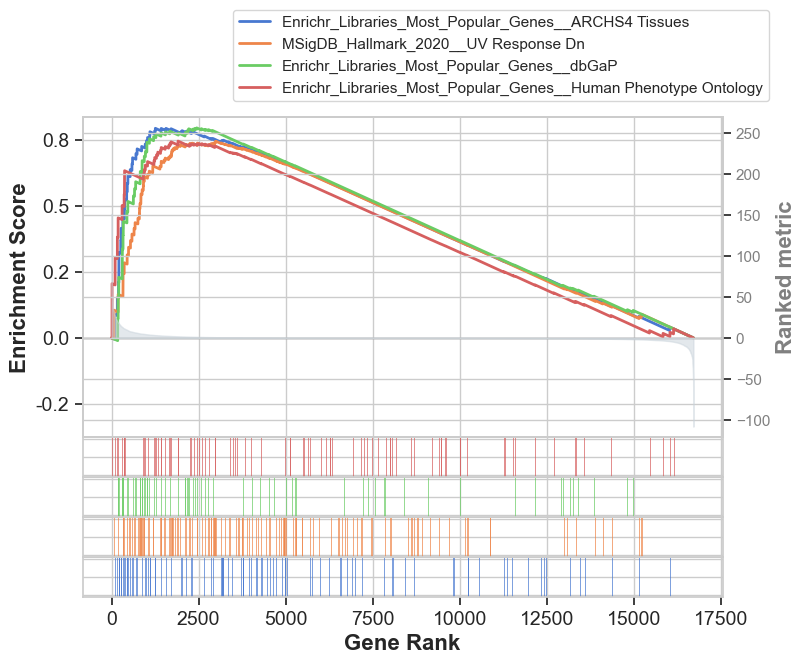

In [54]:
# 1. Seleccionamos las vías (términos) que queremos comparar
# Puedes usar tus strings manuales o sacarlos de los resultados
terms_FT = sig_pathways_FT['Term'].tolist()

# 2. Extraemos los datos necesarios de los resultados (pre_res)
# Usamos una comprensión de lista para obtener 'hits' y 'RES' de cada vía
hits = [pre_res_FT.results[t]['hits'] for t in terms_FT]
runes = [pre_res_FT.results[t]['RES'] for t in terms_FT]

# 3. Graficamos usando gseaplot2
# Esta función está diseñada para encimar las curvas y comparar
fig = gseaplot2(terms=terms_FT, 
                RESs=runes, 
                hits=hits,
                rank_metric=pre_res_FT.ranking, # El ranking es el mismo para todas
                legend_kws={'loc': (0.235, 1.05)}, # Mueve la leyenda fuera de la gráfica
                figsize=(8, 6),
                title="Comparación de Respuesta Biológica")

plt.show()

In [56]:
gsea_FT_results = pre_res_FT.res2d

# 1. Identificamos las vías de interés (basado en tus resultados previos)
vias_objetivo = terms_FT

# 2. Extraemos los genes líderes del DataFrame de resultados
# Filtramos el DataFrame res2d por los términos que queremos
df_lideres_raw = gsea_FT_results[gsea_FT_results['Term'].isin(vias_objetivo)]

# 3. Limpiamos y organizamos
genes_por_via = {}

for _, row in df_lideres_raw.iterrows():
    via = row['Term']
    # En GSEApy, la columna suele llamarse 'Lead_genes'
    # Si te da error, intenta con row['Genes']
    genes_string = row['Lead_genes'] 
    
    lista_genes = genes_string.split(';')
    genes_por_via[via] = lista_genes
    print(f"Vía: {via} -> {len(lista_genes)} genes líderes extraídos con éxito.")

# 4. Guardar para tu validación posterior
# (Usamos este método para manejar listas de diferentes longitudes)
df_final = pd.DataFrame.from_dict(genes_por_via, orient='index').transpose()

# 5. Guardar en .csv
df_final.to_csv("genes_lideres_validados_Macro_DB.csv", index=False)

Vía: Enrichr_Libraries_Most_Popular_Genes__ARCHS4 Tissues -> 26 genes líderes extraídos con éxito.
Vía: MSigDB_Hallmark_2020__UV Response Dn -> 59 genes líderes extraídos con éxito.
Vía: Enrichr_Libraries_Most_Popular_Genes__dbGaP -> 35 genes líderes extraídos con éxito.
Vía: Enrichr_Libraries_Most_Popular_Genes__Human Phenotype Ontology -> 24 genes líderes extraídos con éxito.
